WORK LOG. 

AI usage: CharGpt was used to generate the initial draft of code for notebook and streamlit app. I also asked it for help when errors popped up. In several cases the suggestions weren’t directly applicable (hallucinated APIs, outdated syntax), so the debugging and fixing the issues was on me.

Log:
Unlike previous assignments, this particular assignment was pretty easy and straightforward (apart from the new order of the pages in streamlit. for that, i needed to spend a minute to figure out what goes after what). OpenMeteo appeared to bit a more userfriendly, then Elhub. The anomaly detection was very fun to test. Its fascinating how output changes based on small adjustments of filter inputs. I experimented with the filter parameters and thresholds and watched how tiny tweaks shifted the flagged intervals. That helped me settle on defaults that are conservative enough to avoid false positives but still highlight meaningful deviations. 
In the end, Mongo gave me a little challenge: it didnt like big datasets, so i needed to optimize code, so that it uses smaller portions of data. 
While checking my previous streamlit app, i noticed a problem with a graph, that i havent noticed before. the graph wouldn’t render for 2021. The app claimed there were “no available months,” which I had previously missed. The issue was fixed by using 2025 data instead. It’s a pragmatic workaround so the UI doesn’t break, though I’m not fully sure it’s acceptable. 


gitHub notebook: https://github.com/Viktoria0720/IND320_VY/blob/assignment3/ASSIGNMENTS/PART2/notebooks/IND320_VY_v3.ipynb
github streamlit: https://github.com/Viktoria0720/IND320_VY/blob/assignment3/ASSIGNMENTS/PART1/streamlit_app_1/app.py
Streamlit app: https://ind320vy-assignment3.streamlit.app/

In [1]:
# ---  Imports & plotting defaults ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

from typing import Iterable
from scipy.fft import dct, idct
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.tsa.seasonal import STL
from scipy.signal import spectrogram

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True

# Optional: pretty display of wide DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [2]:
# --- Price areas → city centerpoints DataFrame ---

# This maps the five NO price areas to representative cities and their lat/lon.
# Coordinates are approximate city centers

PRICE_AREAS = [
    {"area": "NO1", "city": "Oslo",         "lat": 59.9139,  "lon": 10.7522},
    {"area": "NO2", "city": "Kristiansand", "lat": 58.1467,  "lon": 7.9956},
    {"area": "NO3", "city": "Trondheim",    "lat": 63.4305,  "lon": 10.3951},
    {"area": "NO4", "city": "Tromsø",       "lat": 69.6492,  "lon": 18.9553},
    {"area": "NO5", "city": "Bergen",       "lat": 60.39299, "lon": 5.32415},
]

locations_df = pd.DataFrame(PRICE_AREAS)[["area", "city", "lon", "lat"]]
locations_df

,area,city,lon,lat
0,NO1,Oslo,10.75220,59.91390
1,NO2,Kristiansand,7.99560,58.14670
2,NO3,Trondheim,10.39510,63.43050
3,NO4,Tromsø,18.95530,69.64920
4,NO5,Bergen,5.32415,60.39299


In [3]:
# Function to download one year's worth of hourly ERA5 reanalysis for a single (lat, lon).
# Adjusted 'hourly_vars' to match the variables in Part 1 (CSV).
OPEN_METEO_BASE = "https://archive-api.open-meteo.com/v1/era5"

def get_era5_hourly(
    lat: float,
    lon: float,
    year: int,
    hourly_vars: Iterable[str] = (
        "temperature_2m",
        "relative_humidity_2m",
        "dew_point_2m",
        "apparent_temperature",
        "surface_pressure",
        "precipitation",
        "rain",
        "snowfall",
        "cloud_cover",
        "wind_speed_10m",
        "wind_direction_10m",
        "shortwave_radiation",
    ),
    timezone: str = "Europe/Oslo",
) -> pd.DataFrame:
    """
    Download hourly ERA5 reanalysis for a given (lat, lon) and year.
    Returns a DataFrame with 'timestamp' and the requested variables.
    """
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{year}-01-01",
        "end_date": f"{year}-12-31",
        "hourly": ",".join(hourly_vars),
        "models": "era5",
        "timezone": timezone,  # Makes times localized to Europe/Oslo in the payload
    }
    r = requests.get(OPEN_METEO_BASE, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    hourly = data.get("hourly", {})
    if not hourly:
        raise ValueError("No 'hourly' payload returned. Check parameters/variables.")
    df = pd.DataFrame(hourly)
    df = df.rename(columns={"time": "timestamp"})
    # API returns local time strings (Europe/Oslo) 
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

# --- Example: Bergen 2019 ---
bergen = next(x for x in PRICE_AREAS if x["city"] == "Bergen")
wx2019_bergen = get_era5_hourly(bergen["lat"], bergen["lon"], 2019)
wx2019_bergen.head()


,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,surface_pressure,precipitation,rain,snowfall,cloud_cover,wind_speed_10m,wind_direction_10m,shortwave_radiation
0,2019-01-01 00:00:00,6.7,81,3.7,-1.0,998.1,0.4,0.4,0.0,91,42.7,261,0.0
1,2019-01-01 01:00:00,6.6,82,3.7,-1.9,997.6,0.5,0.5,0.0,97,48.0,278,0.0
2,2019-01-01 02:00:00,6.8,82,3.9,-1.7,996.5,0.9,0.9,0.0,94,48.6,296,0.0
3,2019-01-01 03:00:00,6.8,83,4.1,-2.2,997.7,0.7,0.7,0.0,97,52.6,310,0.0
4,2019-01-01 04:00:00,6.6,82,3.8,-3.0,999.4,0.6,0.6,0.0,90,55.8,314,0.0


,n,n_outliers,pct_outliers,dct_cutoff,n_sigma,median_SATV,sigma_robust,upper_bound,lower_bound
0,8760,298,3.401826,0.025,2.5,-0.03106,1.264694,3.130676,-3.192796


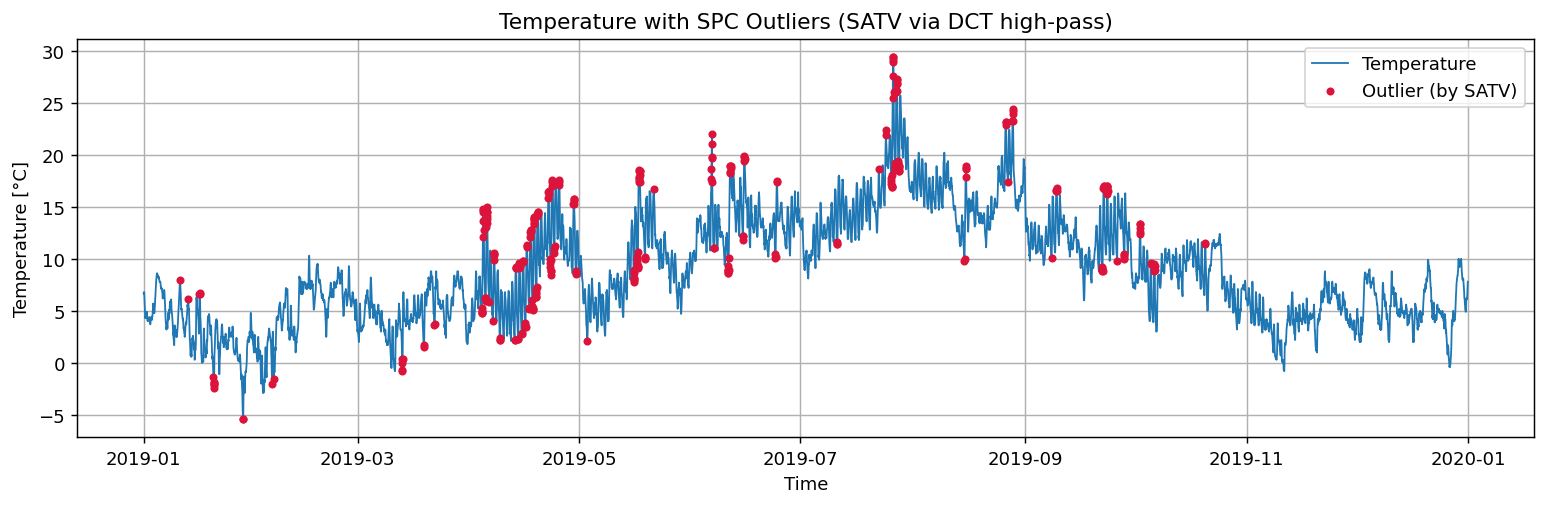

In [4]:
# remove seasonal/low-frequency components from temperature via DCT high-pass,
# obtaining Seasonally Adjusted Temperature Variations (SATV).
# Then compute robust SPC limits using median ± n_sigma * (1.4826 * MAD).
# plot raw temperature and only mark the timestamps flagged by SATV.

def spc_outliers_temperature(
    df: pd.DataFrame,
    time_col: str = "timestamp",
    temp_col: str = "temperature_2m",
    dct_cutoff: float = 0.025,   # fraction of lowest DCT freqs to zero out (0..1)
    n_sigma: float = 2.5,       # robust sigma multiplier
):
    """
    Returns (fig, outliers_df, summary_df).
    """
    ts = df[[time_col, temp_col]].dropna().copy()
    x = ts[temp_col].to_numpy(float)

    # DCT-II forward transform
    X = dct(x, type=2, norm="ortho")

    # Remove low-frequency components
    k = max(1, int(len(X) * dct_cutoff))
    X_hp = X.copy()
    X_hp[:k] = 0.0

    # Inverse transform to obtain SATV
    satv = idct(X_hp, type=2, norm="ortho")
    satv_s = pd.Series(satv, index=ts.index, name="SATV")  # align to rows

    # Robust SPC bounds from SATV
    med = float(np.median(satv))
    mad = float(np.median(np.abs(satv - med)))
    sigma = 1.4826 * mad if mad > 0 else float(np.std(satv))
    upper = med + n_sigma * sigma
    lower = med - n_sigma * sigma

    # Outliers by SATV
    is_out = (satv_s > upper) | (satv_s < lower)  # pandas Series[bool]
    out_df = ts.loc[is_out].assign(SATV=satv_s.loc[is_out])

    # Plot raw temperature; highlight SATV-defined outliers
    fig, ax = plt.subplots()
    ax.plot(ts[time_col], ts[temp_col], linewidth=1.0, label="Temperature")
    ax.scatter(out_df[time_col], out_df[temp_col],
               s=12, color="crimson", label="Outlier (by SATV)", zorder=3)
    ax.set_title("Temperature with SPC Outliers (SATV via DCT high-pass)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature [°C]")
    ax.legend(loc="best")
    fig.tight_layout()

    summary = {
        "n": int(len(ts)),
        "n_outliers": int(is_out.sum()),
        "pct_outliers": float(is_out.mean() * 100.0),
        "dct_cutoff": float(dct_cutoff),
        "n_sigma": float(n_sigma),
        "median_SATV": med,
        "sigma_robust": sigma,
        "upper_bound": upper,
        "lower_bound": lower,
    }
    return fig, out_df, pd.DataFrame([summary])


# --- Test on Bergen 2019 ---
fig_spc, out_points, out_summary = spc_outliers_temperature(wx2019_bergen)
display(out_summary)
plt.show()


,n,n_anomalies,pct_anomalies,contamination
0,8760,86,0.981735,0.01


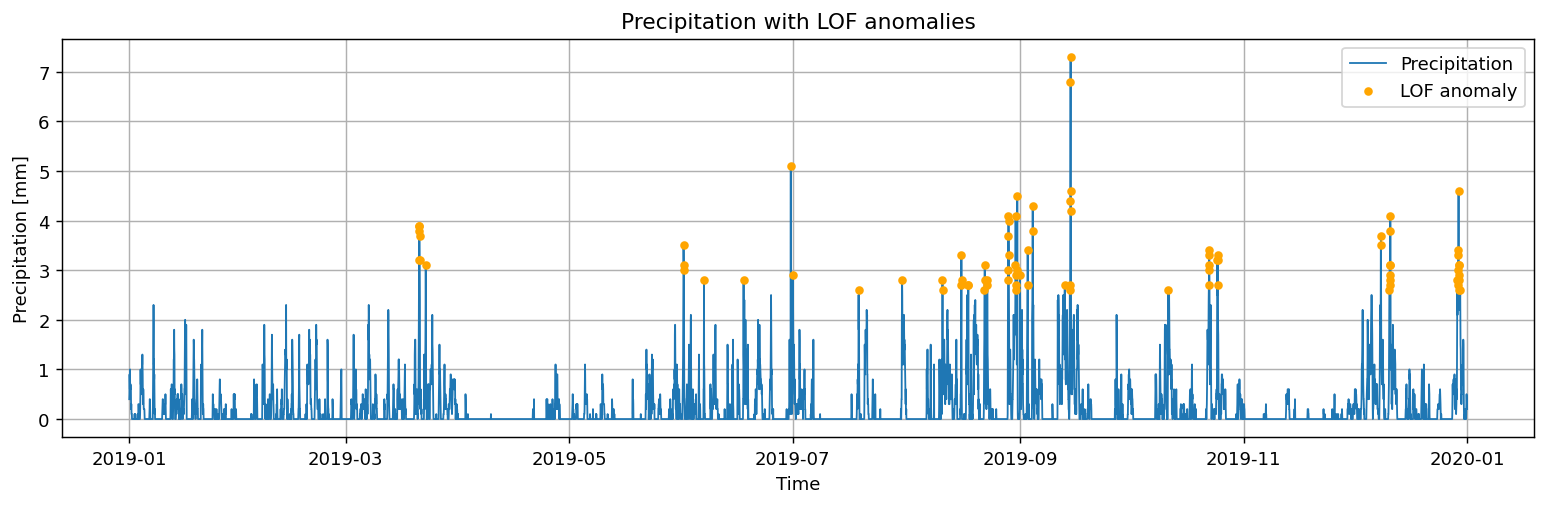

In [5]:
# Local Outlier Factor on the univariate precipitation series.
# 'contamination' controls the proportion flagged as anomalies; default 1% per assignment.

def lof_precip_anomalies(
    df: pd.DataFrame,
    time_col: str = "timestamp",
    precip_col: str = "precipitation",
    contamination: float = 0.01,
):
    """
    Return (fig, anomalies_df, summary_df).
    """
    sub = df[[time_col, precip_col]].dropna().copy()
    y = sub[precip_col].to_numpy(float).reshape(-1, 1)

    lof = LocalOutlierFactor(n_neighbors=35, contamination=contamination)
    labels = lof.fit_predict(y)  # -1 = anomaly; 1 = inlier
    scores = -lof.negative_outlier_factor_
    sub["lof_score"] = scores

    anoms = sub.loc[labels == -1]

    # Plot
    fig, ax = plt.subplots()
    ax.plot(sub[time_col], sub[precip_col], linewidth=1.0, label="Precipitation")
    ax.scatter(anoms[time_col], anoms[precip_col],
               s=14, color="orange", label="LOF anomaly", zorder=3)
    ax.set_title("Precipitation with LOF anomalies")
    ax.set_xlabel("Time")
    ax.set_ylabel("Precipitation [mm]")
    ax.legend(loc="best")
    fig.tight_layout()

    summary = {
        "n": int(len(sub)),
        "n_anomalies": int(len(anoms)),
        "pct_anomalies": float(100 * len(anoms) / max(1, len(sub))),
        "contamination": float(contamination),
    }
    return fig, anoms, pd.DataFrame([summary])

# --- Test on Bergen 2019 ---
fig_lof, anoms_df, anoms_summary = lof_precip_anomalies(wx2019_bergen, contamination=0.01)
display(anoms_summary)
plt.show()


In [12]:

# - time: startTime (ISO UTC string)
# - area: priceArea
# - group: productionGroup (e.g., "hydro")
# - production: quantityKwh

def load_elhub_from_mongo_override(
    coll,
    time_field: str = "startTime",
    area_field: str = "priceArea",
    group_field: str = "productionGroup",
    prod_field: str = "quantityKwh",
    year: int | None = 2025,  # change or set None to load all years
) -> pd.DataFrame:
    proj = {"_id": 0, time_field: 1, prod_field: 1}
    if area_field:  proj[area_field]  = 1
    if group_field: proj[group_field] = 1

    rows = list(coll.find({}, proj))
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    rename = {time_field: "time", prod_field: "production"}
    if area_field:  rename[area_field]  = "area"
    if group_field: rename[group_field] = "group"
    df = df.rename(columns=rename)

    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)
    # convert to Europe/Oslo, drop tz for statsmodels
    df["time"] = df["time"].dt.tz_convert("Europe/Oslo").dt.tz_localize(None)
    df["production"] = pd.to_numeric(df["production"], errors="coerce")

    if year is not None:
        df = df[df["time"].dt.year == year]

    # Clean + nice group casing
    if "group" in df.columns:
        df["group"] = df["group"].astype(str).str.strip().str.replace("_", " ").str.title()

    keep = [c for c in ["time","area","group","production"] if c in df.columns]
    return df[keep].dropna(subset=["time","production"]).sort_values("time").reset_index(drop=True)

# --- Connect to Mongo & load ---
MONGO_URI       = os.getenv("MONGO_URI", "mongodb://localhost:27017")
DB_NAME         = "energy"
COLLECTION_NAME = "elhub_production_2021"  

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
client.admin.command("ping")
coll = client[DB_NAME][COLLECTION_NAME]

prod_df = load_elhub_from_mongo_override(coll, year=2025)  #couldnt use 2021, graph was not working
print(f"Loaded rows: {len(prod_df)}")
display(prod_df.head())

if not prod_df.empty and "time" in prod_df.columns:
    print("Years present:", prod_df["time"].dt.year.value_counts().sort_index())


Loaded rows: 994916


,time,area,group,production
0,2025-09-22 22:00:00,NO2,Solar,135.761
1,2025-09-22 22:00:00,NO4,Thermal,210365.000
2,2025-09-22 22:00:00,NO3,Wind,413855.720
3,2025-09-22 22:00:00,NO4,Hydro,2407737.000
4,2025-09-22 22:00:00,NO4,Solar,0.000


Years present: time
2025    994916
Name: count, dtype: int64


Using: NO2 Solar


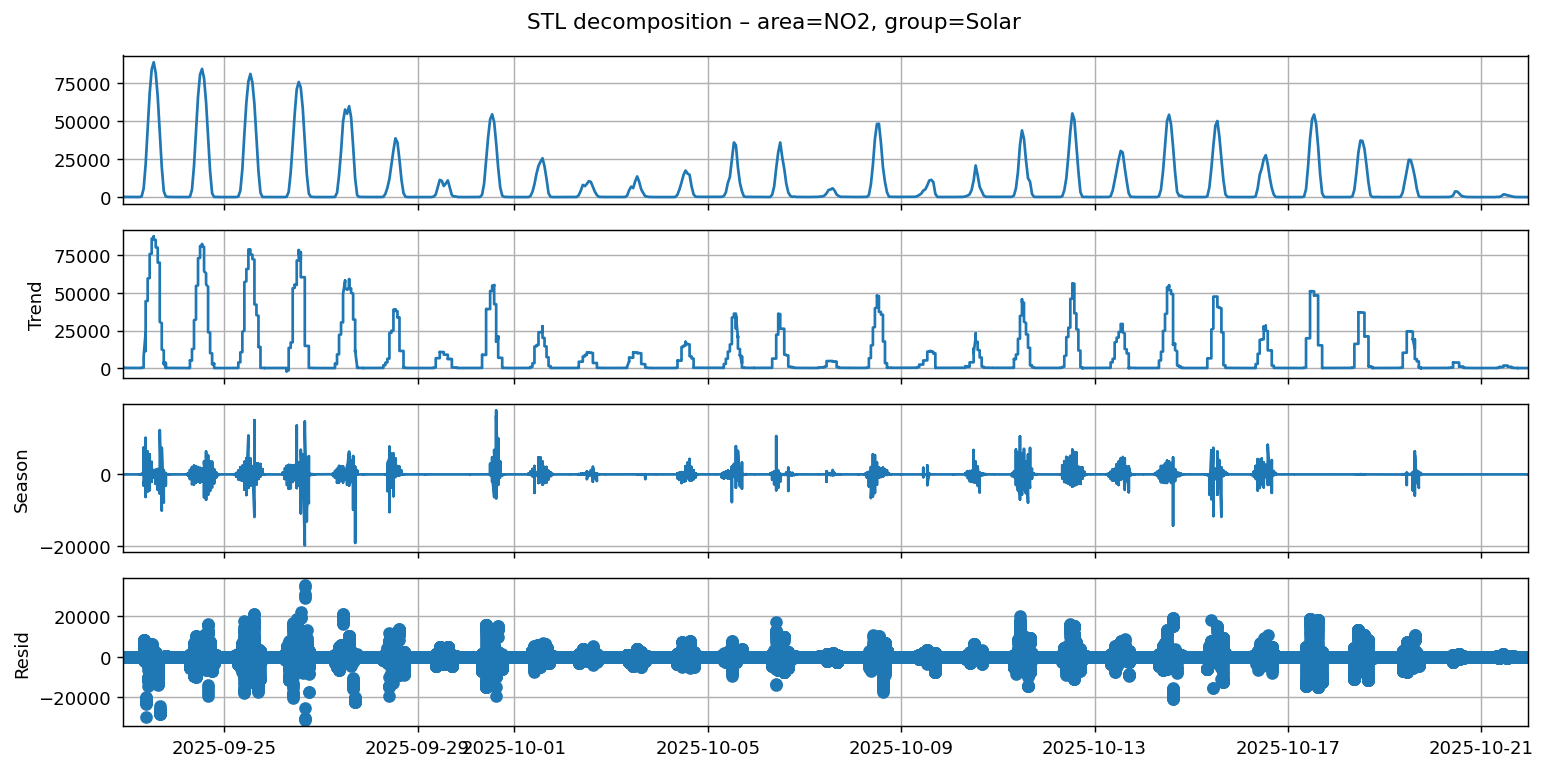

In [13]:
def stl_decompose_production(
    prod_df: pd.DataFrame,
    area: str = "NO5",
    group: str = "Hydro",
    period: int = 24,      # hourly seasonal period; daily data -> 7 or 365
    seasonal: int = 13,
    trend: int = 101,
    robust: bool = True,
):
    """
    Returns (fig, stl_result). Expects columns: time, area, group, production.
    """
    for col in ["time", "production"]:
        if col not in prod_df.columns:
            raise ValueError(f"Missing required column '{col}'")

    df = prod_df.copy()
    if "area" not in df.columns:  df["area"] = area
    if "group" not in df.columns: df["group"] = group

    df = df[(df["area"] == area) & (df["group"] == group)].sort_values("time")
    if df.empty:
        raise ValueError(f"No data for area={area}, group={group}")

    y = pd.Series(df["production"].to_numpy(float), index=pd.to_datetime(df["time"]))
    res = STL(y, period=period, seasonal=seasonal, trend=trend, robust=robust).fit()

    fig = res.plot()
    fig.set_size_inches(12, 6)
    fig.suptitle(f"STL decomposition – area={area}, group={group}")
    fig.tight_layout()
    return fig, res

# Choose existing filters
areas  = prod_df["area"].dropna().unique().tolist() if "area" in prod_df.columns else ["NO1"]
groups = prod_df["group"].dropna().unique().tolist() if "group" in prod_df.columns else ["Hydro"]
AREA_FOR_STL  = areas[0]
GROUP_FOR_STL = groups[0]
print("Using:", AREA_FOR_STL, GROUP_FOR_STL)

# Test
if not prod_df.empty:
    fig_stl, stl_res = stl_decompose_production(
        prod_df,
        area=AREA_FOR_STL,
        group=GROUP_FOR_STL,
        period=24, seasonal=13, trend=101, robust=True
    )
    plt.show()
else:
    print("prod_df is empty; verify Mongo data/year/collection.")


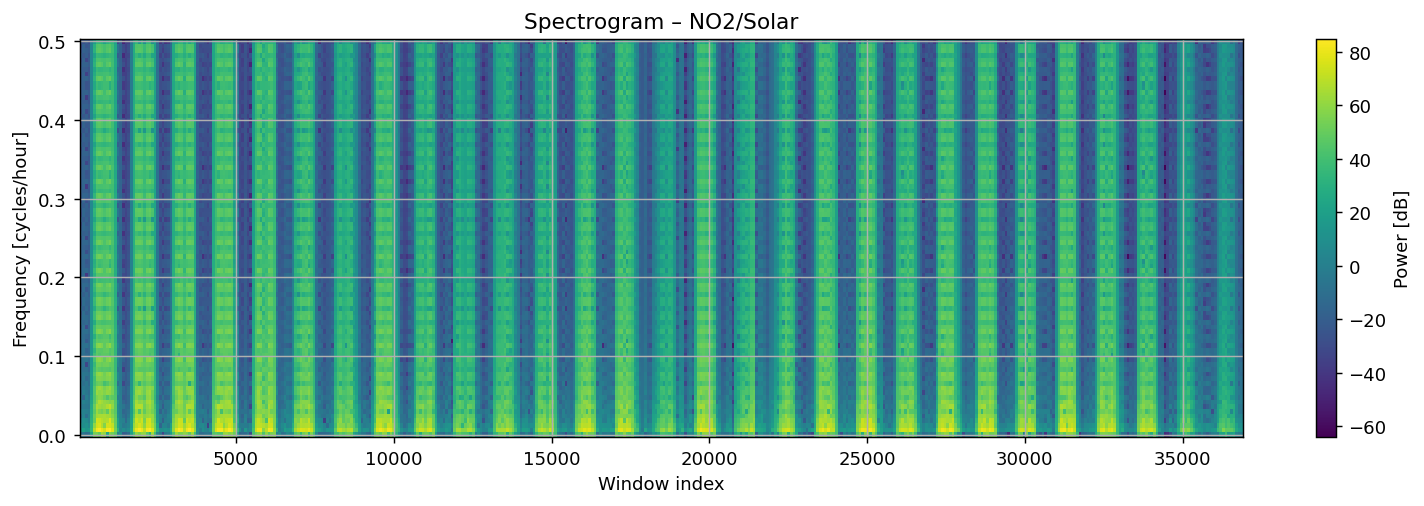

In [14]:
def production_spectrogram(
    prod_df: pd.DataFrame,
    area: str,
    group: str,
    fs: float = 1.0,          # 1 sample per hour
    window_len: int = 7*24,   # one-week window
    overlap: float = 0.5,     # 50% overlap
):
    df = prod_df.copy()
    if "area" not in df.columns:  df["area"] = area
    if "group" not in df.columns: df["group"] = group

    df = df[(df["area"] == area) & (df["group"] == group)].sort_values("time")
    if df.empty:
        raise ValueError(f"No data for area={area}, group={group}")

    x = df["production"].to_numpy(float)
    nperseg = int(window_len)
    noverlap = int(overlap * nperseg)
    f, t, Sxx = spectrogram(x, fs=fs, nperseg=nperseg, noverlap=noverlap, scaling="spectrum")

    fig, ax = plt.subplots()
    im = ax.pcolormesh(t, f, 10*np.log10(Sxx + 1e-12), shading="auto")
    ax.set_title(f"Spectrogram – {area}/{group}")
    ax.set_xlabel("Window index")
    ax.set_ylabel("Frequency [cycles/hour]")
    fig.colorbar(im, ax=ax, label="Power [dB]")
    fig.tight_layout()
    return fig, (f, t, Sxx)

# Test
if not prod_df.empty:
    fig_spec, _ = production_spectrogram(
        prod_df,
        area=AREA_FOR_STL,
        group=GROUP_FOR_STL,
        window_len=24*7,
        overlap=0.5
    )
    plt.show()
else:
    print("prod_df is empty; verify Mongo data/year/collection.")
